Phase 1.2 & 1.3: Softmax Regression Modeling & Rigorous Evaluation

In [1]:
# Import libraries
import pandas as pd
from datasets import load_dataset
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib
import os

# Load all official splits
dataset = load_dataset("hpe-ai/medical-cases-classification-tutorial")
df_train = dataset['train'].to_pandas()
df_val = dataset['validation'].to_pandas()
df_test = dataset['test'].to_pandas()

print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")

# Combine text fields for richer context
df_train['combined_text'] = df_train['description'] + " " + df_train['transcription']
df_val['combined_text'] = df_val['description'] + " " + df_val['transcription']
df_test['combined_text'] = df_test['description'] + " " + df_test['transcription']

print("\n✅ Combined text fields created!")

/home/tharu/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Repo card metadata block was not found. Setting CardData to empty.


Train: 1724 | Val: 370 | Test: 370

✅ Combined text fields created!


In [2]:
# Create the full pipeline with improvements
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True,
        stop_words='english',
        max_features=10000,
        ngram_range=(1, 3),
        min_df=2,
        max_df=0.85,
        sublinear_tf=True
    )),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        solver='lbfgs',
        max_iter=1000,
        random_state=42
    ))
])

# Train the model
print("\n🔍 Training model with combined text...")
pipeline.fit(df_train['combined_text'], df_train['medical_specialty'])
print("✅ Model trained successfully!")


🔍 Training model with combined text...
✅ Model trained successfully!


In [3]:
# Hyperparameter tuning
param_grid = {
    'tfidf__max_features': [8000, 10000],
    'tfidf__ngram_range': [(1, 2)],
    'classifier__C': [0.5, 1, 5]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(df_train['combined_text'], df_train['medical_specialty'])

print(f"\n✅ Grid Search Complete!")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 6 candidates, totalling 18 fits

✅ Grid Search Complete!
Best parameters: {'classifier__C': 5, 'tfidf__max_features': 10000, 'tfidf__ngram_range': (1, 2)}
Best CV Accuracy: 0.8103



🎯 FINAL TEST ACCURACY: 0.7757
Final Classification Report (Test Set):
                            precision    recall  f1-score   support

Cardiovascular / Pulmonary       0.96      0.92      0.94       109
      ENT - Otolaryngology       0.71      0.71      0.71        14
          Gastroenterology       0.93      0.93      0.93        41
     Hematology - Oncology       0.55      0.80      0.65        15
                Nephrology       1.00      0.70      0.82        10
                 Neurology       0.64      0.64      0.64        47
              Neurosurgery       0.42      0.55      0.48        20
   Obstetrics / Gynecology       0.96      0.69      0.80        32
             Ophthalmology       0.82      0.82      0.82        11
                Orthopedic       0.79      0.67      0.72        57
     Pediatrics - Neonatal       0.38      1.00      0.55         3
   Psychiatry / Psychology       0.78      0.78      0.78         9
                 Radiology       0.00      0

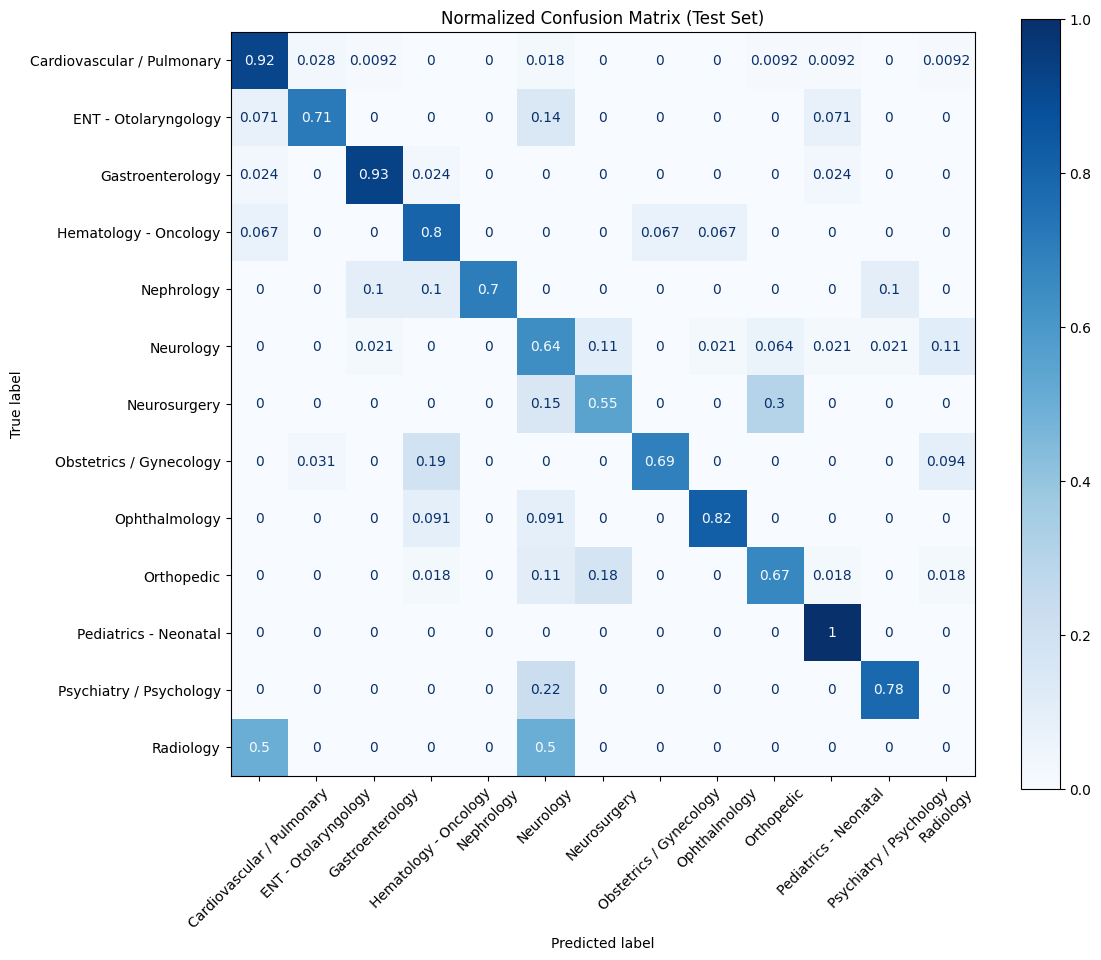


⚠️ Specialties with <50% Precision or Recall:
Specialty                      Recall     Precision  Support   
Neurosurgery                   0.55       0.42       20        
Pediatrics - Neonatal          1.00       0.38       3         
Radiology                      0.00       0.00       2         


In [4]:
# Use best model
best_pipeline = grid_search.best_estimator_

# Final evaluation on test set
y_test_pred = best_pipeline.predict(df_test['combined_text'])
y_test_true = df_test['medical_specialty']

test_acc = accuracy_score(y_test_true, y_test_pred)
print(f"\n{'='*60}")
print(f"🎯 FINAL TEST ACCURACY: {test_acc:.4f}")
print(f"{'='*60}")

print("Final Classification Report (Test Set):")
print(classification_report(
    y_test_true,
    y_test_pred,
    zero_division=0
))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_estimator(
    best_pipeline,
    df_test['combined_text'],
    y_test_true,
    ax=ax,
    cmap=plt.cm.Blues,
    normalize='true',
    xticks_rotation=45
)
plt.title("Normalized Confusion Matrix (Test Set)")
plt.show()

# Identify problem specialties
report_dict = classification_report(y_test_true, y_test_pred, output_dict=True, zero_division=0)
problem_specialties = []
for cls, metrics in report_dict.items():
    if isinstance(metrics, dict):
        if metrics['recall'] < 0.5 or metrics['precision'] < 0.5:
            problem_specialties.append((cls, metrics['recall'], metrics['precision'], metrics['support']))

print("\n⚠️ Specialties with <50% Precision or Recall:")
print(f"{'Specialty':<30} {'Recall':<10} {'Precision':<10} {'Support':<10}")
print("="*60)
for spec, recall, precision, support in problem_specialties:
    print(f"{spec:<30} {recall:<10.2f} {precision:<10.2f} {int(support):<10}")

In [5]:
# Save to /artifacts at PROJECT ROOT 
os.makedirs('../artifacts', exist_ok=True)
joblib.dump(best_pipeline, '../artifacts/model.joblib')
print("✅ Model saved to /artifacts/model.joblib")

✅ Model saved to /artifacts/model.joblib
